In [1]:
!pip3 install -U ucimlrepo 

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [2]:
!pip install openpyxl

In [12]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -----------------------------

In [18]:
!pip install seaborn

In [6]:
import pandas as pd

file_path = 'Online Retail.xlsx' 


df = pd.read_excel(file_path)

print("DataFrame 'df' loaded successfully.")

DataFrame 'df' loaded successfully.


In [7]:
import pandas as pd
import numpy as np

# 1. Remove rows with missing CustomerID 
df.dropna(subset=['CustomerID'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int)

# 2. Filter out cancelled transactions (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3.Total Sales (Monetary value per transaction line)
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [8]:
# snapshot date (one day after the last transaction in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#RFM metrics
rfm_df = df.groupby('CustomerID').agg(
    # Recency: Days since last purchase
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    
    # Frequency: Total number of unique invoices
    Frequency=('InvoiceNo', 'nunique'),
    
    # Monetary: Total sales amount
    Monetary=('Sales', 'sum')
)

rfm_df = rfm_df.reset_index()

print("RFM Features (X) Preview:")
print(rfm_df.head())

RFM Features (X) Preview:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [9]:
quantiles = rfm_df['Monetary'].quantile([0.33, 0.66]).to_dict()


def monetary_segment(monetary_value):
    if monetary_value <= quantiles[0.33]:
        return 'Low Value'
    elif monetary_value <= quantiles[0.66]:
        return 'Medium Value'
    else:
        return 'High Value'

rfm_df['Customer_Value_Class'] = rfm_df['Monetary'].apply(monetary_segment)

print("\nTarget Variable (y) Distribution:")
print(rfm_df['Customer_Value_Class'].value_counts())


Target Variable (y) Distribution:
Customer_Value_Class
High Value      1475
Low Value       1432
Medium Value    1432
Name: count, dtype: int64


In [10]:
X = rfm_df[['Recency', 'Frequency', 'Monetary']]

y = rfm_df['Customer_Value_Class']

print(f"\nShape of Features (X): {X.shape}")
print(f"Shape of Target (y): {y.shape}")


Shape of Features (X): (4339, 3)
Shape of Target (y): (4339,)


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train) # Training the model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, accuracy_score
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

1.0
              precision    recall  f1-score   support

  High Value       1.00      1.00      1.00       457
   Low Value       1.00      1.00      1.00       416
Medium Value       1.00      1.00      1.00       429

    accuracy                           1.00      1302
   macro avg       1.00      1.00      1.00      1302
weighted avg       1.00      1.00      1.00      1302



Matplotlib is building the font cache; this may take a moment.


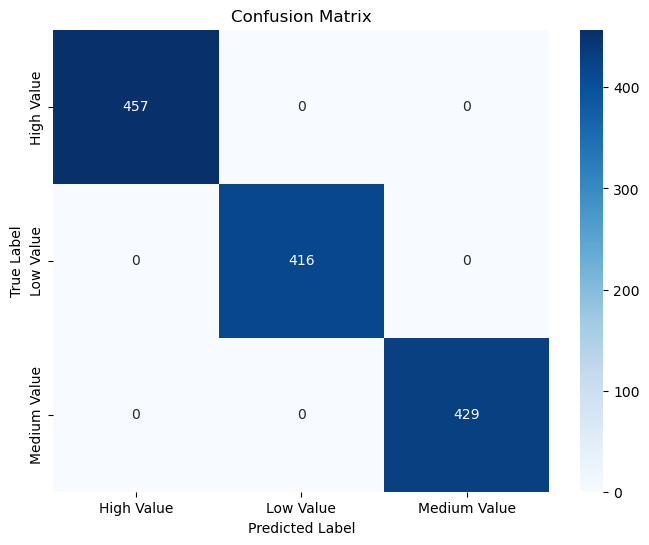

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [21]:
import joblib
import os 
from sklearn.ensemble import RandomForestClassifier

model_filename = 'customer_value_classifier.joblib'

joblib.dump(model, model_filename)

print(f"Model successfully saved as: {model_filename}")

Model successfully saved as: customer_value_classifier.joblib
